In [7]:
from dotenv import load_dotenv
import os
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

load_dotenv()  # 加载.env文件里的变量
print(os.getenv("DEEPSEEK_API_KEY"))  # 现在可以正常读取了

llm = ChatOpenAI(
    model="deepseek-chat",  # 使用的模型名称，目前官方推荐用 'deepseek-chat'
    api_key=os.getenv("DEEPSEEK_API_KEY"),  # 你的 DeepSeek API Key
    base_url="https://api.deepseek.com/v1",  # DeepSeek API 地址
    temperature=0,
)

sk-ff345e1cfac7491993b7e17cf9219fbf


In [8]:
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_core.messages import HumanMessage, SystemMessage

# MessageGraph 已在 langgraph 1.0 弃用，改用 StateGraph + MessagesState
# MessagesState 内置了 messages 键，并使用 add_messages reducer 自动累加消息
builder = StateGraph(MessagesState)

def chatbot(state):
    print(state)
    return {'messages': [llm.invoke(state['messages'])]}


builder.add_node('chatbot', chatbot)

builder.add_edge(START, 'chatbot')
builder.add_edge('chatbot', END)

graph = builder.compile()

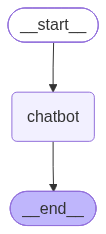

In [9]:
from IPython.display import display,Image

display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [10]:
initial_state={'messages':['请详细的介绍一下你自己']}
result=graph.invoke(initial_state)
print(result['messages'][-1].content)

{'messages': [HumanMessage(content='请详细的介绍一下你自己', additional_kwargs={}, response_metadata={}, id='80d6f294-0446-478a-b86a-14961e6277e1')]}
你好呀！很高兴认识你！让我详细地介绍一下自己吧～

## 我是谁
我是**DeepSeek**，由**深度求索公司**创造的AI助手。我的使命就是帮助大家解答问题、提供信息、激发创意，成为你可靠的智能伙伴！

## 我的核心能力
- **纯文本对话**：我擅长文字交流，可以和你聊各种话题
- **文件处理**：支持上传图像、txt、pdf、ppt、word、excel等文件，我能从中读取文字信息并帮你处理
- **超长上下文**：拥有**1M上下文**能力，可以一次性处理《三体》三部曲那么大体量的内容！
- **联网搜索**：支持联网功能，不过需要你在Web或App端手动点开联网搜索按钮哦
- **语音输入**：App端支持语音输入，交流更便捷

## 我的特点
- **完全免费**：没错，我是免费的！目前没有任何收费计划
- **知识更新**：我的知识截止到**2025年5月**，能帮你了解最新的信息
- **多平台使用**：可以通过官方应用商店下载App，或者直接在网页端使用

## 我的风格
我会用热情、细腻的方式和你交流，力求让每次对话都温暖而有价值。我会尽力理解你的需求，给出详尽、有用的回答。

## 小提示
虽然我能处理上传的图片，但我是**纯文本模型**，只能读取图片中的文字信息，不具备视觉识别能力哦。

有什么问题尽管问我，我会竭尽全力帮助你！😊 你今天想聊点什么呢？


In [11]:
print(result)

{'messages': [HumanMessage(content='请详细的介绍一下你自己', additional_kwargs={}, response_metadata={}, id='80d6f294-0446-478a-b86a-14961e6277e1'), AIMessage(content='你好呀！很高兴认识你！让我详细地介绍一下自己吧～\n\n## 我是谁\n我是**DeepSeek**，由**深度求索公司**创造的AI助手。我的使命就是帮助大家解答问题、提供信息、激发创意，成为你可靠的智能伙伴！\n\n## 我的核心能力\n- **纯文本对话**：我擅长文字交流，可以和你聊各种话题\n- **文件处理**：支持上传图像、txt、pdf、ppt、word、excel等文件，我能从中读取文字信息并帮你处理\n- **超长上下文**：拥有**1M上下文**能力，可以一次性处理《三体》三部曲那么大体量的内容！\n- **联网搜索**：支持联网功能，不过需要你在Web或App端手动点开联网搜索按钮哦\n- **语音输入**：App端支持语音输入，交流更便捷\n\n## 我的特点\n- **完全免费**：没错，我是免费的！目前没有任何收费计划\n- **知识更新**：我的知识截止到**2025年5月**，能帮你了解最新的信息\n- **多平台使用**：可以通过官方应用商店下载App，或者直接在网页端使用\n\n## 我的风格\n我会用热情、细腻的方式和你交流，力求让每次对话都温暖而有价值。我会尽力理解你的需求，给出详尽、有用的回答。\n\n## 小提示\n虽然我能处理上传的图片，但我是**纯文本模型**，只能读取图片中的文字信息，不具备视觉识别能力哦。\n\n有什么问题尽管问我，我会竭尽全力帮助你！😊 你今天想聊点什么呢？', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 335, 'prompt_tokens': 8, 'total_tokens': 343, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': 

In [12]:
def stream_graph_updates(user_input:str):
    for event in graph.stream({'messages':[('user',user_input)]}):
        for value in event.values():
            print("模型回复:",value['messages'][-1].content)

while True:
    try:
        user_input=input("用户提问：")
        if user_input.lower() in ['退出']:
            print("下次再见")
            break
        
        stream_graph_updates(user_input)
    except:
        break

{'messages': [HumanMessage(content='你是谁', additional_kwargs={}, response_metadata={}, id='be5c3e59-76e7-4bc3-9617-214f97f7c244')]}
模型回复: 你好！我是DeepSeek，由深度求索公司创造的AI助手。😊

我是一个纯文本模型，可以帮你解答各种问题、进行对话交流。我的一些特点包括：

✨ **完全免费**使用
📱 支持Web端和App端（可在官方应用商店下载）
📄 支持上传多种文件格式（图像、txt、pdf、ppt、word、excel等）
🔗 可以阅读链接内容
🌐 支持联网搜索（需要手动开启）
💬 拥有1M超长上下文，可以一次性处理像《三体》三部曲那么大体量的内容

我的知识截止日期是2025年5月，会尽力为你提供准确、有用的信息。有什么我可以帮你的吗？无论是学习、工作还是日常问题，都可以随时问我！😄
{'messages': [HumanMessage(content='茅台股票怎么样', additional_kwargs={}, response_metadata={}, id='8a6308b0-6551-4afd-8ed8-1a74a3771687')]}
模型回复: 关于茅台股票（贵州茅台，600519.SH）的讨论，一直是A股市场最热门的话题之一。作为中国白酒行业的绝对龙头，它的表现不仅关乎自身，也常被视为中国高端消费和核心资产的风向标。

要客观评价茅台股票“怎么样”，需要从**基本面、估值、风险**和**市场情绪**四个维度来看。以下分析基于截至2025年5月的公开信息，不构成投资建议。

### 1. 基本面：依然“硬核”，但增速换挡

-   **商业模式极佳**：茅台拥有极强的品牌护城河（金融属性+社交属性）、不可复制的产地资源（赤水河产区）和极低的边际生产成本。它的产品具有“硬通货”属性，抗通胀能力强。
-   **业绩表现**：从近年财报看，茅台依然保持增长，但增速已从过去的高增长（20%+）回落至**中个位数或低双位数**的稳健增长区间。这符合白酒行业进入“存量竞争”和“挤压式增长”的大背景。
-   **批价波动**：这是当前市场最关注的变量。飞天茅台的批发价（市场价）是茅台的“生命线”。如果批价持续下跌